# MALLORN Astronominal Classification - XGBoost model v2

## 1. Nạp metadata (train/test log)
Đọc `train_log.csv`, `test_log.csv` và tạo bảng `meta_train/meta_test` chứa `object_id`, `Z`, `EBV`, `target`, `split`.

In [9]:

import os, gc, json
import numpy as np
import pandas as pd

BASE_PATH = os.environ.get("MALLORN_BASE_PATH", r"/kaggle/input/mallorn/")

TRAIN_LOG = os.path.join(BASE_PATH, "train_log.csv")
TEST_LOG  = os.path.join(BASE_PATH, "test_log.csv")

train_log = pd.read_csv(TRAIN_LOG)
test_log  = pd.read_csv(TEST_LOG)

meta_train = train_log[["object_id","Z","EBV","target","split"]].copy()
meta_test  = test_log[["object_id","Z","EBV","split"]].copy()

print("train:", meta_train.shape, "test:", meta_test.shape)
meta_train.head()


train: (3043, 5) test: (7135, 4)


,object_id,Z,EBV,target,split
0,Dornhoth_fervain_onodrim,3.0490,0.110,0,split_01
1,Dornhoth_galadh_ylf,0.4324,0.058,0,split_01
2,Elrim_melethril_thul,0.4673,0.577,0,split_01
3,Ithil_tobas_rodwen,0.6946,0.012,0,split_01
4,Mirion_adar_Druadan,0.4161,0.058,0,split_01


## 2. I/O & xây dựng bảng đặc trưng theo split
Đọc `*_full_lightcurves.csv` theo từng thư mục split và trích xuất đặc trưng cho từng `object_id`.

In [10]:

# ============================================================
# FAST I/O: đọc mỗi split đúng 1 lần khi build feature
# ============================================================
def _read_split_lightcurves(split_name: str, kind: str):
    fname = f"{kind}_full_lightcurves.csv"
    path = os.path.join(BASE_PATH, split_name, fname)
    return pd.read_csv(path)

def _get_flux_err(df):
    # cố gắng bắt các tên cột sai số hay gặp
    for c in ["Flux Error","Flux_Error","flux_err","flux_error","FluxErr","FluxUnc","Flux Unc","flux_unc"]:
        if c in df.columns:
            return df[c].values.astype(np.float64)
    return None

def build_feature_table(meta: pd.DataFrame, kind: str, extract_fn):
    '''
    meta: dataframe có object_id, split, (và Z/EBV/target nếu train)
    kind: "train" hoặc "test"
    extract_fn: function(df_object)->dict features
    '''
    rows = []
    for split_name, sub in meta.groupby("split"):
        df = _read_split_lightcurves(split_name, kind=kind)
        want = set(sub["object_id"].values.tolist())
        df = df[df["object_id"].isin(want)]
        # chuẩn hoá tên cột để đồng bộ
        if "Time (MJD)" not in df.columns and "time" in df.columns:
            df["Time (MJD)"] = df["time"]
        if "Flux" not in df.columns and "flux" in df.columns:
            df["Flux"] = df["flux"]
        if "Filter" not in df.columns and "filter" in df.columns:
            df["Filter"] = df["filter"]

        for oid, dfo in df.groupby("object_id"):
            feat = extract_fn(dfo)
            feat["object_id"] = oid
            rows.append(feat)

        del df
        gc.collect()
    return pd.DataFrame(rows)


## 3. Trích xuất đặc trưng từ lightcurve
Gồm:
- **BASE features**: thống kê theo thời gian/band, peak, độ biến thiên, outlier…
- **Shape features**: rise/decay/peak (lọc theo band ưu tiên)
- **PROD addon**: cadence/SNR/band coverage (ổn định, ít overfit)


In [11]:
import numpy as np
import pandas as pd

def tde_shape_features(df, band_priority=("r","i","g","z","y","u")):
    """
    Tính các đặc trưng shape (rise/decay/peak) cho 1 object.
    df: dataframe với cột [Time, Flux, Filter]
    Trả về dict feature.
    """
    feat = {}
    
    # --- chọn filter đại diện ---
    d = None
    chosen_band = None
    for b in band_priority:
        tmp = df[df["Filter"] == b]
        if len(tmp) >= 5:   # cần đủ điểm để tính slope
            d = tmp
            chosen_band = b
            break
    if d is None:
        # fallback: dùng tất cả filter gộp
        d = df.copy()
        chosen_band = "all"
    
    feat["shape_band"] = chosen_band
    
    # sort theo thời gian
    d = d.sort_values("Time (MJD)")
    t = d["Time (MJD)"].values.astype(float)
    f = d["Flux"].values.astype(float)
    
    n = len(d)
    if n < 5:
        # không đủ điểm → trả về 0
        feat.update({
            "peak_flux": 0.0,
            "t_peak_norm": 0.5,
            "amp_flux": 0.0,
            "rise_time_10_90": 0.0,
            "decay_time_90_10": 0.0,
            "asymmetry_rise_decay": 0.0
        })
        return feat
    
    # --- smoothing nhẹ để giảm nhiễu ---
    f_smooth = pd.Series(f).rolling(
        window=3, center=True, min_periods=1
    ).median().values
    
    # --- baseline: median 20% thời gian đầu ---
    k_early = max(1, int(round(0.2 * n)))
    baseline = np.median(f_smooth[:k_early])
    
    # --- peak ---
    idx_peak = np.argmax(f_smooth)
    peak_flux = f_smooth[idx_peak]
    t_peak = t[idx_peak]
    
    duration = t.max() - t.min()
    if duration <= 0:
        t_peak_norm = 0.5
    else:
        t_peak_norm = (t_peak - t.min()) / duration
    
    amp = peak_flux - baseline
    
    feat["peak_flux"] = float(peak_flux)
    feat["t_peak_norm"] = float(t_peak_norm)
    feat["amp_flux"] = float(amp)
    
    # nếu amplitude không dương ⇒ không có "peak" rõ
    if amp <= 0:
        feat["rise_time_10_90"] = 0.0
        feat["decay_time_90_10"] = 0.0
        feat["asymmetry_rise_decay"] = 0.0
        return feat
    
    # --- mức 10% và 90% ---
    f10 = baseline + 0.10 * amp
    f90 = baseline + 0.90 * amp
    
    # tìm thời điểm đầu tiên f_smooth >= f10 & f90 trước peak (rise)
    rise_mask = np.arange(n) <= idx_peak
    t_rise = t[rise_mask]
    f_rise = f_smooth[rise_mask]
    
    def first_cross(time_arr, val_arr, level):
        """ tạm thời: trả về time của phần tử đầu tiên >= level """
        idx = np.where(val_arr >= level)[0]
        if len(idx) == 0:
            return None
        return time_arr[idx[0]]
    
    def last_cross(time_arr, val_arr, level):
        idx = np.where(val_arr >= level)[0]
        if len(idx) == 0:
            return None
        return time_arr[idx[-1]]
    
    t10_rise = first_cross(t_rise, f_rise, f10)
    t90_rise = first_cross(t_rise, f_rise, f90)
    
    # decay: sau peak
    decay_mask = np.arange(n) >= idx_peak
    t_dec = t[decay_mask]
    f_dec = f_smooth[decay_mask]
    
    # trên đoạn decay, ta nhìn điểm từ cao tới thấp → dùng last_cross
    t90_dec = last_cross(t_dec, f_dec, f90)
    t10_dec = last_cross(t_dec, f_dec, f10)
    
    # tính thời gian nếu đủ điểm
    if (t10_rise is not None) and (t90_rise is not None):
        rise_time = max(0.0, float(t90_rise - t10_rise))
    else:
        rise_time = 0.0
    
    if (t90_dec is not None) and (t10_dec is not None):
        decay_time = max(0.0, float(t10_dec - t90_dec))
    else:
        decay_time = 0.0
    
    feat["rise_time_10_90"] = rise_time
    feat["decay_time_90_10"] = decay_time
    
    if decay_time > 0:
        feat["asymmetry_rise_decay"] = rise_time / decay_time
    else:
        feat["asymmetry_rise_decay"] = 0.0
    
    return feat

In [12]:
import numpy as np
import pandas as pd

def safe_polyfit_1d(x, y):
    """
    Fit y = a*x + b, trả về (a, b).
    An toàn: lọc nan/inf, clip cực trị, check đủ điểm & đủ variance.
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    # remove nan/inf
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if x.size < 5:
        return None

    # tránh case x gần như hằng số
    if np.nanstd(x) < 1e-12:
        return None

    # clip y để tránh outlier phá SVD
    y = np.clip(y, np.quantile(y, 0.01), np.quantile(y, 0.99))

    # dùng lstsq (ổn định hơn polyfit trong một số case)
    A = np.vstack([x, np.ones_like(x)]).T
    try:
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        a, b = coef[0], coef[1]
        return float(a), float(b)
    except np.linalg.LinAlgError:
        return None

def safe_polyfit_1d(x, y, min_points=3):
    """
    Fit y = a*x + b an toàn.
    Trả về (a, b) hoặc None.
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if x.size < min_points:
        return None
    if np.nanstd(x) < 1e-12:
        return None

    # clip y để tránh outliers làm hỏng SVD
    if y.size >= 10:
        lo, hi = np.quantile(y, 0.01), np.quantile(y, 0.99)
        if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
            y = np.clip(y, lo, hi)

    A = np.vstack([x, np.ones_like(x)]).T
    try:
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        return float(coef[0]), float(coef[1])
    except np.linalg.LinAlgError:
        return None



def tde_advanced_shape_features(df):
    feat = {}

    # chọn filter đại diện
    for b in ["r","i","g","z","y","u"]:
        d = df[df["Filter"] == b]
        if len(d) >= 10:
            break
    if len(d) < 10:
        d = df.copy()  # dùng mọi filter
    
    d = d.sort_values("Time (MJD)")
    t = d["Time (MJD)"].values
    f = d["Flux"].values

    n = len(d)
    if n < 10:
        # fallback
        for k in [
            "powerlaw_decay", "exp_decay_k", "peak_width_50",
            "percentile_p10", "percentile_p90", "percentile_range",
            "early_late_flux_ratio", "color_shift",
            "multi_peak_lag_rg", "smoothness",
            "slope_std_4seg", "rising_tail_len", "falling_tail_len",
            "zero_crossings", "peak_asymmetry",
            "dt_iqr", "energy", "filter_drift", "rise_sharpness",
        ]:
            feat[k] = 0.0
        return feat

    # smoothing
    f_s = pd.Series(f).rolling(3, center=True, min_periods=1).median().values

    # baseline
    baseline = np.median(f_s[:int(0.2*n)])
    amp = f_s.max() - baseline

    # peak
    idx_peak = np.argmax(f_s)
    t_peak = t[idx_peak]

    # 1. POWER-LAW DECAY INDEX
    # if n - idx_peak > 5 and amp > 0:
    #     tt = t[idx_peak+1:] - t_peak
    #     ff = f_s[idx_peak+1:]
    #     good = (tt > 0) & (ff > 0)
    #     if good.sum() >= 5:
    #         slope, _ = np.polyfit(np.log(tt[good]), np.log(ff[good]), 1)
    #         feat["powerlaw_decay"] = slope  # TDE ~ -1.6
    #     else:
    #         feat["powerlaw_decay"] = 0.0
    # else:
    #     feat["powerlaw_decay"] = 0.0

    # 1. POWER-LAW DECAY INDEX (SAFE)
    if n - idx_peak > 5 and amp > 0:
        tt = t[idx_peak+1:] - t_peak
        ff = f_s[idx_peak+1:]

        ok = (tt > 0) & (ff > 0) & np.isfinite(tt) & np.isfinite(ff)
        tt = tt[ok]
        ff = ff[ok]

        if tt.size >= 5:
            xlog = np.log(tt)
            ylog = np.log(np.clip(ff, 1e-6, None))
            fit = safe_polyfit_1d(xlog, ylog)
            feat["powerlaw_decay"] = fit[0] if fit is not None else 0.0
        else:
            feat["powerlaw_decay"] = 0.0
    else:
        feat["powerlaw_decay"] = 0.0


    # 2. EXPONENTIAL DECAY FIT
    # if n - idx_peak > 5:
    #     tt = t[idx_peak+1:] - t_peak
    #     ff = f_s[idx_peak+1:]
    #     mask = tt > 0
    #     if mask.sum() >= 5:
    #         y = np.log(np.clip(ff[mask], 1e-6, None))
    #         k, _ = np.polyfit(tt[mask], y, 1)
    #         feat["exp_decay_k"] = k  # SN: k ~ -0.1 .. -0.3
    #     else:
    #         feat["exp_decay_k"] = 0.0
    # else:
    #     feat["exp_decay_k"] = 0.0
    # 2. EXPONENTIAL DECAY FIT (SAFE)
    if n - idx_peak > 5:
        tt = t[idx_peak+1:] - t_peak
        ff = f_s[idx_peak+1:]
        mask = (tt > 0) & np.isfinite(tt) & np.isfinite(ff)
        tt = tt[mask]
        ff = ff[mask]
    # cần đủ điểm và ff > 0 để log
        pos = ff > 0
        tt = tt[pos]
        ff = ff[pos]

        if tt.size >= 5:
            ylog = np.log(np.clip(ff, 1e-6, None))

            fit = safe_polyfit_1d(tt, ylog)
            if fit is not None:
                k, b = fit
                feat["exp_decay_k"] = k
            else:
                feat["exp_decay_k"] = 0.0
        else:
            feat["exp_decay_k"] = 0.0
    else:
        feat["exp_decay_k"] = 0.0


    # 3. Peak Width (50%)
    half = baseline + 0.5*amp
    above = np.where(f_s >= half)[0]
    if len(above) > 2:
        feat["peak_width_50"] = t[above[-1]] - t[above[0]]
    else:
        feat["peak_width_50"] = 0.0

    # 4. Percentiles
    p10 = np.quantile(f_s, 0.10)
    p90 = np.quantile(f_s, 0.90)
    feat["percentile_p10"] = p10
    feat["percentile_p90"] = p90
    feat["percentile_range"] = p90 - p10

    # 5. Early/Late flux ratio
    early = f_s[:int(0.3*n)].mean()
    late = f_s[int(0.7*n):].mean()
    feat["early_late_flux_ratio"] = late / (early + 1e-3)

    # 6. Color shift (g-r)
    for col_band in ["g","r"]:
        if col_band not in df["Filter"].unique():
            g_med_early = r_med_early = 0.0
            g_med_late = r_med_late = 0.0
            break
    df_g = df[df.Filter=="g"].sort_values("Time (MJD)")
    df_r = df[df.Filter=="r"].sort_values("Time (MJD)")
    if len(df_g)>5 and len(df_r)>5:
        ng = len(df_g)
        nr = len(df_r)
        g_e = df_g["Flux"].values[:int(0.3*ng)]
        g_l = df_g["Flux"].values[int(0.7*ng):]
        r_e = df_r["Flux"].values[:int(0.3*nr)]
        r_l = df_r["Flux"].values[int(0.7*nr):]
        color_e = np.median(g_e) - np.median(r_e)
        color_l = np.median(g_l) - np.median(r_l)
        feat["color_shift"] = color_l - color_e
    else:
        feat["color_shift"] = 0.0

    # 7. Multi-band peak lag: r vs g
    def get_peak_time(df_band):
        if len(df_band)<5: return None
        ds = df_band.sort_values("Time (MJD)")
        fs = ds["Flux"].rolling(3,center=True,min_periods=1).median().values
        return ds["Time (MJD)"].values[np.argmax(fs)]
    pt_r = get_peak_time(df[df.Filter=="r"])
    pt_g = get_peak_time(df[df.Filter=="g"])
    if pt_r is not None and pt_g is not None:
        feat["multi_peak_lag_rg"] = pt_g - pt_r
    else:
        feat["multi_peak_lag_rg"] = 0.0

    # 8. Smoothness
    roll = pd.Series(f).rolling(3,center=True,min_periods=1).mean().values
    feat["smoothness"] = np.mean(np.abs(f - roll))

    # 9. slope stability 4 segments
    # seg_len = n // 4
    # slopes = []
    # for k in range(4):
    #     start = k * seg_len
    #     end = start + seg_len
    #     if end - start >= 3:
    #         tt = t[start:end]
    #         ff = f_s[start:end]
    #         m, _ = np.polyfit(tt, ff, 1)
    #         slopes.append(m)
    # feat["slope_std_4seg"] = np.std(slopes) if len(slopes)>1 else 0.0
    seg_len = n // 4
    slopes = []
    for k in range(4):
        start = k * seg_len
        end = start + seg_len if k < 3 else n  # segment cuối lấy đến hết

        if end - start >= 3:
            tt = t[start:end]
            ff = f_s[start:end]

            fit = safe_polyfit_1d(tt, ff, min_points=3)
            if fit is not None:
                m, b = fit
                slopes.append(m)

    feat["slope_std_4seg"] = float(np.std(slopes)) if len(slopes) > 1 else 0.0
    feat["slope_mean_4seg"] = float(np.mean(slopes)) if len(slopes) > 0 else 0.0
    feat["slope_range_4seg"] = float(np.max(slopes) - np.min(slopes)) if len(slopes) > 1 else 0.0


    # 10. Rising / falling tail length
    feat["rising_tail_len"] = idx_peak
    feat["falling_tail_len"] = n - idx_peak

    # 11. zero crossings (around baseline)
    signs = np.sign(f_s - baseline)
    changes = np.where(np.diff(signs)!=0)[0]
    feat["zero_crossings"] = len(changes)

    # 12. peak asymmetry
    idx10 = np.where(f_s >= baseline + 0.1*amp)[0]
    idx90 = np.where(f_s >= baseline + 0.9*amp)[0]
    if len(idx10)>0 and len(idx90)>0:
        t10 = t[idx10[0]]
        t90 = t[idx90[-1]]
        feat["peak_asymmetry"] = (t_peak - t10)/(t90 - t_peak + 1e-6)
    else:
        feat["peak_asymmetry"] = 0.0

    # 13. time-gaps iqr
    dt = np.diff(t)
    feat["dt_iqr"] = np.quantile(dt, 0.75) - np.quantile(dt, 0.25)

    # 14. energy
    feat["energy"] = np.sum(f_s * np.hstack([dt, dt[-1] if len(dt)>0 else 0]))

    # 15. filter drift
    peak_vals = []
    for b in ["u","g","r","i","z","y"]:
        db = df[df.Filter==b]
        if len(db)>3:
            fs = db["Flux"].rolling(3,center=True,min_periods=1).median().values
            peak_vals.append(fs.max())
    feat["filter_drift"] = np.std(peak_vals) if len(peak_vals)>0 else 0.0

    # 16. rise sharpness
    dt_f = np.diff(f_s) / (dt + 1e-6) if len(dt)>0 else [0]
    feat["rise_sharpness"] = np.max(dt_f)

    return feat


In [13]:
from scipy.stats import skew, kurtosis
import numpy as np

def _mad(x):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.median(x)
    return np.median(np.abs(x - med))

def _iqr(x):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    q25, q75 = np.percentile(x, [25, 75])
    return float(q75 - q25)

def _safe_skew(x):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < 3:
        return 0.0
    try:
        v = float(skew(x))
        return 0.0 if not np.isfinite(v) else v
    except Exception:
        return 0.0

def _safe_kurtosis(x):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < 4:
        return 0.0
    try:
        v = float(kurtosis(x))
        return 0.0 if not np.isfinite(v) else v
    except Exception:
        return 0.0

def _trimmed_mean(x, trim=0.10):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    x = np.sort(x)
    k = int(np.floor(trim * x.size))
    if x.size - 2*k <= 0:
        return float(np.mean(x))
    return float(np.mean(x[k:-k]))

def _baseline_and_peak(t, f, frac_early=0.20):
    # baseline = median of early segment (first frac_early of time range)
    if t.size == 0:
        return (np.nan, np.nan, np.nan, np.nan)
    t0 = np.nanmin(t)
    t1 = np.nanmax(t)
    dur = max(0.0, float(t1 - t0))
    if dur == 0.0:
        base = float(np.nanmedian(f))
        peak = float(np.nanmax(f))
        return base, peak, base, peak

    t_cut = t0 + frac_early * dur
    early = f[t <= t_cut]
    if early.size < 3:
        early = f
    base = float(np.nanmedian(early))
    peak = float(np.nanmax(f))
    return base, peak, float(np.nanmedian(early)), peak

def _time_above_threshold(t, f, thr):
    # approximate: sum dt where consecutive points both above threshold
    if t.size < 2:
        return 0.0
    idx = np.argsort(t)
    t = t[idx]
    f = f[idx]
    ok = np.isfinite(t) & np.isfinite(f)
    t = t[ok]; f = f[ok]
    if t.size < 2:
        return 0.0
    dt = np.diff(t)
    above = f > thr
    return float(np.sum(dt * (above[:-1] & above[1:])))

def extract_features(df):
    feat = {}
    if df is None or len(df) == 0:
        # trả feature rỗng tối thiểu để không crash
        feat["n_obs"] = 0
        feat["duration"] = 0.0
        feat["flux_mean"] = np.nan
        feat["flux_std"] = np.nan
        feat["shape_band"] = "all"
        return feat

    d0 = df.sort_values("Time (MJD)").copy()
    t_all = d0["Time (MJD)"].values.astype(np.float64)
    f_all = d0["Flux"].values.astype(np.float64)

    # --------------------------
    # Tổng quan
    # --------------------------
    feat["n_obs"] = int(len(d0))
    feat["duration"] = float(np.nanmax(t_all) - np.nanmin(t_all)) if len(t_all) else 0.0
    # --------------------------
    # Cadence / gaps (irregular timestamps)  [MALLORN_production-inspired]
    # --------------------------
    if len(t_all) >= 2:
        tt = np.sort(t_all)
        dt = np.diff(tt)
        feat["dt_mean"]   = float(np.mean(dt))
        feat["dt_median"] = float(np.median(dt))
        feat["dt_std"]    = float(np.std(dt))
        feat["dt_min"]    = float(np.min(dt))
        feat["dt_max"]    = float(np.max(dt))
        feat["dt_iqr"]    = float(np.subtract(*np.percentile(dt, [75, 25])))
        feat["max_gap"]   = float(np.max(dt))
        for gthr in [2, 5, 10, 20]:
            feat[f"n_gaps_gt{gthr}"] = int(np.sum(dt > gthr))
        mu, sd = float(np.mean(dt)), float(np.std(dt))
        feat["burstiness"] = float((sd - mu) / (sd + mu + 1e-9))
    else:
        for k in ["dt_mean","dt_median","dt_std","dt_min","dt_max","dt_iqr","max_gap","burstiness"]:
            feat[k] = 0.0
        for gthr in [2, 5, 10, 20]:
            feat[f"n_gaps_gt{gthr}"] = 0

    # --------------------------
    # If flux uncertainty exists -> SNR stats (noise-aware)
    # --------------------------
    err_all = None
    for c in ["Flux Error","Flux_Error","flux_err","flux_error","FluxErr","FluxUnc","Flux Unc","flux_unc"]:
        if c in d0.columns:
            err_all = d0[c].values.astype(np.float64)
            break
    if err_all is not None and len(err_all) == len(f_all):
        snr = f_all / (err_all + 1e-9)
        snr_abs = np.abs(snr)
        feat["snr_abs_mean"] = float(np.nanmean(snr_abs))
        feat["snr_abs_max"]  = float(np.nanmax(snr_abs))
        feat["snr_pos_max"]  = float(np.nanmax(snr))
        feat["snr_frac_abs_gt3"] = float(np.nanmean(snr_abs > 3.0))
        feat["snr_frac_abs_gt5"] = float(np.nanmean(snr_abs > 5.0))
    else:
        for k in ["snr_abs_mean","snr_abs_max","snr_pos_max","snr_frac_abs_gt3","snr_frac_abs_gt5"]:
            feat[k] = 0.0


    # --------------------------
    # Flux: thống kê thường + robust
    # --------------------------
    feat["flux_mean"] = float(np.nanmean(f_all))
    feat["flux_std"] = float(np.nanstd(f_all))
    feat["flux_median"] = float(np.nanmedian(f_all))
    feat["flux_iqr"] = _iqr(f_all)
    feat["flux_mad"] = _mad(f_all)
    feat["flux_p01"] = float(np.nanpercentile(f_all, 1))
    feat["flux_p99"] = float(np.nanpercentile(f_all, 99))
    feat["flux_trimmed_mean_10"] = _trimmed_mean(f_all, trim=0.10)
    feat["flux_skew"] = _safe_skew(f_all)
    feat["flux_kurtosis"] = _safe_kurtosis(f_all)
    feat["flux_max"] = float(np.nanmax(f_all))
    feat["flux_min"] = float(np.nanmin(f_all))
    feat["flux_range"] = feat["flux_max"] - feat["flux_min"]

    # clipped max/min (giảm đuôi dài)
    p01 = feat["flux_p01"]; p99 = feat["flux_p99"]
    f_clip = np.clip(f_all, p01, p99)
    feat["flux_clip_max"] = float(np.nanmax(f_clip))
    feat["flux_clip_min"] = float(np.nanmin(f_clip))
    feat["flux_clip_std"] = float(np.nanstd(f_clip))

    # --------------------------
    # Baseline-relative (transient "eventness")
    # --------------------------
    base, peak, base_early, peak2 = _baseline_and_peak(t_all, f_all, frac_early=0.20)
    feat["base_early_med"] = float(base_early)
    feat["peak_flux"] = float(peak)
    feat["peak_minus_base"] = float(peak - base_early)
    feat["peak_over_base"] = float((peak - base_early) / (abs(base_early) + 1e-6))

    mad_early = _mad(f_all[t_all <= (np.nanmin(t_all) + 0.20*feat["duration"])] if feat["duration"]>0 else f_all)
    sigma = 1.4826 * mad_early if np.isfinite(mad_early) and mad_early > 0 else float(np.nanstd(f_all) + 1e-6)
    feat["peak_significance"] = float((peak - base_early) / (sigma + 1e-6))

    thr3 = base_early + 3.0 * sigma
    feat["frac_pts_above_base3sig"] = float(np.mean(f_all > thr3))
    feat["time_above_base3sig"] = _time_above_threshold(t_all, f_all, thr3)

    # --------------------------
    # Per-filter stats + missing flags
    # --------------------------
    filters = ["u", "g", "r", "i", "z", "y"]
    for band in filters:
        d = d0[d0["Filter"] == band]
        feat[f"has_{band}"] = int(len(d) > 0)
        feat[f"nobs_{band}"] = int(len(d))
        if len(d) > 0:
            tb = d["Time (MJD)"].values.astype(np.float64)
            fb = d["Flux"].values.astype(np.float64)
            # per-band cadence/gaps
            if len(tb) >= 2:
                tbs = np.sort(tb)
                dtb = np.diff(tbs)
                feat[f"{band}_cad_median"] = float(np.median(dtb))
                feat[f"{band}_cad_iqr"]    = float(np.subtract(*np.percentile(dtb, [75, 25])))
                feat[f"{band}_cad_std"]    = float(np.std(dtb))
                feat[f"{band}_max_gap"]    = float(np.max(dtb))
                for gthr in [5, 10, 20]:
                    feat[f"{band}_n_gaps_gt{gthr}"] = int(np.sum(dtb > gthr))
            else:
                feat[f"{band}_cad_median"] = 0.0
                feat[f"{band}_cad_iqr"]    = 0.0
                feat[f"{band}_cad_std"]    = 0.0
                feat[f"{band}_max_gap"]    = 0.0
                for gthr in [5, 10, 20]:
                    feat[f"{band}_n_gaps_gt{gthr}"] = 0
            feat[f"{band}_duration"] = float(np.nanmax(tb) - np.nanmin(tb)) if len(tb) else 0.0

            feat[f"{band}_mean"] = float(np.nanmean(fb))
            feat[f"{band}_std"] = float(np.nanstd(fb))
            feat[f"{band}_median"] = float(np.nanmedian(fb))
            feat[f"{band}_iqr"] = _iqr(fb)
            feat[f"{band}_mad"] = _mad(fb)
            feat[f"{band}_max"] = float(np.nanmax(fb))
            feat[f"{band}_min"] = float(np.nanmin(fb))

            # baseline-relative theo band
            base_b, peak_b, base_b_early, _ = _baseline_and_peak(tb, fb, frac_early=0.20)
            mad_b_early = _mad(fb[tb <= (np.nanmin(tb) + 0.20*(feat[f"{band}_duration"]))] if feat[f"{band}_duration"]>0 else fb)
            sigma_b = 1.4826 * mad_b_early if np.isfinite(mad_b_early) and mad_b_early > 0 else float(np.nanstd(fb) + 1e-6)

            feat[f"{band}_peak_minus_base"] = float(peak_b - base_b_early)
            feat[f"{band}_peak_sig"] = float((peak_b - base_b_early) / (sigma_b + 1e-6))
        else:
            # để NaN (xgboost handle missing), đồng thời có has_{band} để phân biệt
            feat[f"{band}_duration"] = 0.0
            for k in ["mean","std","median","iqr","mad","max","min","peak_minus_base","peak_sig"]:
                feat[f"{band}_{k}"] = np.nan

    # --------------------------
    # Shape features (đã có)
    # --------------------------
    shape_feat = tde_shape_features(d0)
    feat.update(shape_feat)
    feat.update(tde_advanced_shape_features(d0))

    return feat

In [14]:

# ============================================================
# Production-inspired "SAFE" addon features (from MALLORN_production ideas)
# - cadence stats: irregular timestamps (global)
# - SNR stats nếu có flux_err (noise-aware)
# - rest-frame scaling theo (1+Z) sẽ làm ở bước merge meta
# Mục tiêu: thêm ít feature nhưng ổn định, tránh overfit.
# ============================================================

def _cadence_basic(t):
    t = np.asarray(t, dtype=np.float64)
    t = t[np.isfinite(t)]
    if t.size < 3:
        return {"dt_median": 0.0, "dt_iqr": 0.0, "max_gap": 0.0}
    t = np.sort(t)
    dt = np.diff(t)
    dt = dt[np.isfinite(dt)]
    if dt.size == 0:
        return {"dt_median": 0.0, "dt_iqr": 0.0, "max_gap": 0.0}
    q25, q75 = np.quantile(dt, [0.25, 0.75])
    return {
        "dt_median": float(np.median(dt)),
        "dt_iqr": float(q75 - q25),
        "max_gap": float(np.max(dt)),
    }

def _snr_basic(flux, err):
    flux = np.asarray(flux, dtype=np.float64)
    err  = np.asarray(err, dtype=np.float64)
    ok = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    if ok.sum() < 5:
        return {"snr_mean": 0.0, "snr_max": 0.0, "snr_frac_gt3": 0.0, "snr_frac_gt5": 0.0}
    snr = np.abs(flux[ok] / err[ok])
    return {
        "snr_mean": float(np.mean(snr)),
        "snr_max": float(np.max(snr)),
        "snr_frac_gt3": float(np.mean(snr > 3.0)),
        "snr_frac_gt5": float(np.mean(snr > 5.0)),
    }

def extract_features_prod(df):
    """Baseline extract_features + addon cadence/SNR (an toàn)."""
    feat = extract_features(df)  # baseline của bạn
    if df is None or len(df) == 0:
        return feat

    d0 = df.sort_values("Time (MJD)")
    t_all = d0["Time (MJD)"].values.astype(np.float64)
    f_all = d0["Flux"].values.astype(np.float64)

    # cadence (global)
    cad = _cadence_basic(t_all)
    feat["cad_dt_median"] = cad["dt_median"]
    feat["cad_dt_iqr"]    = cad["dt_iqr"]
    feat["cad_max_gap"]   = cad["max_gap"]

    # band coverage (rất rẻ nhưng hữu ích)
    if "Filter" in d0.columns:
        for b in ["u","g","r","i","z","y"]:
            feat[f"n_{b}"] = int((d0["Filter"].values == b).sum())
        counts = np.array([feat[f"n_{b}"] for b in ["u","g","r","i","z","y"]], dtype=np.float64)
        p = counts / max(1.0, counts.sum())
        feat["band_entropy"] = float(-(p[p>0] * np.log(p[p>0] + 1e-12)).sum())

    # SNR (nếu có flux_err)
    err = _get_flux_err(d0)
    if err is not None:
        feat.update(_snr_basic(f_all, err))

    return feat


## 4. Build feature table cho train (BASE vs PROD) + meta interactions
Tạo 2 bảng đặc trưng để so sánh (ablation), sau đó thêm các tương tác dựa trên `Z`, `EBV`.

In [15]:

# ============================================================
# Build feature tables: baseline vs baseline+prod (ablation)
# ============================================================
print(">> Build baseline features ...")
df_feat_base = build_feature_table(meta_train, kind="train", extract_fn=extract_features)
df_train_base = df_feat_base.merge(meta_train, on="object_id", how="left")

print(">> Build production-inspired features ...")
df_feat_prod = build_feature_table(meta_train, kind="train", extract_fn=extract_features_prod)
df_train_prod = df_feat_prod.merge(meta_train, on="object_id", how="left")

print("base:", df_train_base.shape, "prod:", df_train_prod.shape)

def add_meta_interactions(df):
    df = df.copy()
    z = df["Z"].astype(float).clip(lower=0.0)
    inv_1pz = 1.0 / (1.0 + z)
    df["inv_1pz"] = inv_1pz
    if "duration" in df.columns:
        df["duration_rf"] = df["duration"].astype(float) * inv_1pz

    ebv = df["EBV"].abs().astype(float)
    df["ebv_abs"] = ebv
    if "peak_minus_base" in df.columns:
        df["amp_over_ebv"] = df["peak_minus_base"].astype(float) / (ebv + 0.05)
    if "peak_significance" in df.columns:
        df["peak_sig_over_ebv"] = df["peak_significance"].astype(float) / (ebv + 0.05)
    return df

df_train_base = add_meta_interactions(df_train_base)
df_train_prod = add_meta_interactions(df_train_prod)

df_train_base.head()


>> Build baseline features ...


/tmp/ipykernel_55/643122975.py:69: RuntimeWarning: All-NaN slice encountered
  base = float(np.nanmedian(early))
/tmp/ipykernel_55/643122975.py:71: RuntimeWarning: All-NaN slice encountered
  return base, peak, float(np.nanmedian(early)), peak
/tmp/ipykernel_55/643122975.py:223: RuntimeWarning: Mean of empty slice
  feat[f"{band}_mean"] = float(np.nanmean(fb))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_55/643122975.py:225: RuntimeWarning: All-NaN slice encountered
  feat[f"{band}_median"] = float(np.nanmedian(fb))
/tmp/ipykernel_55/643122975.py:228: RuntimeWarning: All-NaN slice encountered
  feat[f"{band}_max"] = float(np.nanmax(fb))
/tmp/ipykernel_55/643122975.py:229: RuntimeWarning: All-NaN slice encountered
  feat[f"{band}_min"] = float(np.nanmin(fb))
/tmp/ipykernel_55/643122975.py:61: RuntimeWarning: All-NaN slice encoun

>> Build production-inspired features ...


/tmp/ipykernel_55/643122975.py:69: RuntimeWarning: All-NaN slice encountered
  base = float(np.nanmedian(early))
/tmp/ipykernel_55/643122975.py:71: RuntimeWarning: All-NaN slice encountered
  return base, peak, float(np.nanmedian(early)), peak
/tmp/ipykernel_55/643122975.py:223: RuntimeWarning: Mean of empty slice
  feat[f"{band}_mean"] = float(np.nanmean(fb))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_55/643122975.py:225: RuntimeWarning: All-NaN slice encountered
  feat[f"{band}_median"] = float(np.nanmedian(fb))
/tmp/ipykernel_55/643122975.py:228: RuntimeWarning: All-NaN slice encountered
  feat[f"{band}_max"] = float(np.nanmax(fb))
/tmp/ipykernel_55/643122975.py:229: RuntimeWarning: All-NaN slice encountered
  feat[f"{band}_min"] = float(np.nanmin(fb))
/tmp/ipykernel_55/643122975.py:61: RuntimeWarning: All-NaN slice encoun

base: (3043, 187) prod: (3043, 197)


,n_obs,duration,dt_mean,dt_median,dt_std,dt_min,dt_max,dt_iqr,max_gap,n_gaps_gt2,...,object_id,Z,EBV,target,split,inv_1pz,duration_rf,ebv_abs,amp_over_ebv,peak_sig_over_ebv
0,65,1254.2719,19.597998,4.4010,43.308947,0.0,264.0572,41.809050,264.0572,37,...,Dornhoth_fervain_onodrim,3.0490,0.110,0,split_01,0.246975,309.773253,0.110,162.712672,255.174433
1,167,2362.1560,14.229855,2.5676,32.170954,0.0,231.0805,93.074050,231.0805,106,...,Dornhoth_galadh_ylf,0.4324,0.058,0,split_01,0.698129,1649.089640,0.058,104.461506,200.194268
2,35,1206.0218,35.471229,2.1691,77.411190,0.0,336.2111,29.825125,336.2111,19,...,Elrim_melethril_thul,0.4673,0.577,0,split_01,0.681524,821.932665,0.577,15.318430,3.026335
3,798,2858.4129,3.586465,0.0000,13.746918,0.0,157.5278,8.592425,157.5278,354,...,Ithil_tobas_rodwen,0.6946,0.012,0,split_01,0.590110,1686.777352,0.012,87.828149,422.302847
4,129,2202.3065,17.205520,4.4178,46.107888,0.0,340.1757,55.223300,340.1757,81,...,Mirion_adar_Druadan,0.4161,0.058,0,split_01,0.706165,1555.191371,0.058,50.059379,91.714572


## 5. Huấn luyện XGBoost + OOF + tối ưu ngưỡng F1
- GroupKFold theo `split`
- Tối ưu ngưỡng dựa trên OOF probability để tối đa F1.

In [16]:

from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold, ParameterSampler
from sklearn.metrics import f1_score
import joblib, json
import numpy as np
import pandas as pd
import re

# ==============================
# Encode FIX: shape_band mapping cố định
# ==============================
BAND_MAP = {"u":0,"g":1,"r":2,"i":3,"z":4,"y":5,"all":6}

def prepare_X(df):
    df_enc = df.copy()
    # fixed mapping for shape_band
    if "shape_band" in df_enc.columns:
        df_enc["shape_band"] = df_enc["shape_band"].map(BAND_MAP).fillna(-1).astype(int)

    # Drop ids/labels
    y = df_enc["target"].astype(int).values
    groups = df_enc["split"].values if "split" in df_enc.columns else None

    X = df_enc.drop(columns=["target"], errors="ignore")
    X = X.drop(columns=["object_id"], errors="ignore")  # keep split for grouping only
    # keep split out of features
    X = X.drop(columns=["split"], errors="ignore")

    # Encode any remaining object columns deterministically (by sorting unique values)
    obj_cols = X.select_dtypes(include=["object"]).columns.tolist()
    cat_maps = {}
    for col in obj_cols:
        vals = X[col].astype(str).fillna("__nan__")
        cats = sorted(vals.unique().tolist())
        m = {c:i for i,c in enumerate(cats)}
        X[col] = vals.map(m).fillna(-1).astype(int)
        cat_maps[col] = m

    # drop constant cols
    nun = X.nunique(dropna=False)
    drop_cols = nun[nun <= 1].index.tolist()
    if drop_cols:
        X = X.drop(columns=drop_cols)

    feature_cols = X.columns.tolist()
    return X, y, groups, feature_cols, drop_cols, cat_maps

def select_feature_subset(feature_cols, mode="all"):
    """
    mode:
      - all: tất cả
      - shape: tập trung shape/peak/time-above + meta (Z/EBV)
      - band: tập trung per-band coverage/missing/peak_sig + meta
      - cadence: cadence/gap + meta
    """
    cols = feature_cols

    # always keep meta
    keep_always = set([c for c in cols if c in ["Z","EBV","inv_1pz","duration_rf"]])

    if mode == "all":
        return cols

    sel = set()
    if mode == "shape":
        pats = [
            r"^(peak_|amp_|t_peak|rise_|decay_|asymmetry_|smoothness|energy|zero_crossings|time_above|frac_pts_above)",
            r"^(base_|flux_|duration$|dt_)",
            r"^early_late_",
        ]
        for c in cols:
            if any(re.search(p, c) for p in pats):
                sel.add(c)

    elif mode == "band":
        pats = [
            r"^has_[ugrizy]$",
            r"^nobs_[ugrizy]$",
            r"^[ugrizy]_(mean|std|median|iqr|mad|max|min|peak_minus_base|peak_sig|duration|cad_.*)$",
            r"^band_entropy$",
            r"^n_bands_present$",
        ]
        for c in cols:
            if any(re.search(p, c) for p in pats):
                sel.add(c)

    elif mode == "cadence":
        pats = [
            r"^(cad_|dt_)",
            r"^n_gaps_",
            r"^burst_",
            r"^max_gap$",
            r"^cadence_",
            r"^[ugrizy]_cad_",
            r"^[ugrizy]_max_gap$",
            r"^[ugrizy]_n_gaps_",
            r"^(n_obs$|duration$)",
        ]
        for c in cols:
            if any(re.search(p, c) for p in pats):
                sel.add(c)

    sel |= keep_always
    # ensure non-empty
    out = [c for c in cols if c in sel]
    if len(out) == 0:
        out = [c for c in cols if c in keep_always]
    if len(out) == 0:
        return cols
    return out

def find_best_threshold(y_true, proba, steps=1001):
    # scan thresholds in [0,1]
    best_f1, best_th = -1.0, 0.5
    for th in np.linspace(0, 1, steps):
        pred = (proba >= th).astype(int)
        f1 = f1_score(y_true, pred)
        if f1 > best_f1:
            best_f1, best_th = f1, th
    return float(best_f1), float(best_th)

def _predict_proba_best(clf, X):
    """Predict proba, ưu tiên dùng best_iteration nếu model có early-stopping."""
    try:
        # xgboost>=1.6 hỗ trợ iteration_range
        bi = getattr(clf, "best_iteration", None)
        if bi is not None:
            return clf.predict_proba(X, iteration_range=(0, int(bi) + 1))[:, 1]
    except TypeError:
        pass
    return clf.predict_proba(X)[:, 1]

def oof_xgb(X, y, groups, params, n_splits=5, seed=42, early_stopping_rounds=80):
    """OOF bằng GroupKFold theo `split`.

    Trả về:
      - oof_proba: (n_samples,)
      - models: list model theo fold
      - best_iters: list best_iteration theo fold (nếu có), để chọn best_n khi train full
    """
    gkf = GroupKFold(n_splits=n_splits)
    oof = np.zeros(len(y), dtype=float)
    models, best_iters = [], []

    for fold, (tr, va) in enumerate(gkf.split(X, y, groups)):
        X_tr, y_tr = X.iloc[tr], y[tr]
        X_va, y_va = X.iloc[va], y[va]

        clf = XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            random_state=seed + fold,
            early_stopping_rounds=early_stopping_rounds,
            **params
        )

        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False,
        )

        oof[va] = _predict_proba_best(clf, X_va)
        models.append(clf)

        bi = getattr(clf, "best_iteration", None)
        if bi is None:
            bi = params.get("n_estimators", 0) - 1
        best_iters.append(int(bi))

    return oof, models, best_iters

def train_full_xgb(X, y, params, seed=42):
    """Train full model (không early-stopping)."""
    clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        random_state=seed,
        **params
    )
    clf.fit(X, y, verbose=False)
    return clf

# ============================================================
# Choose feature set: baseline vs prod (keep ablation from earlier)
# ============================================================
def eval_table(df_train, tag):
    X, y, groups, feat_cols, drop_cols, cat_maps = prepare_X(df_train)
    # minimal baseline params (stable)
    base_params = dict(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,
        min_child_weight=2.0,
        gamma=0.0
    )
    oof, _, _ = oof_xgb(X, y, groups, base_params, n_splits=5, seed=42)
    best_f1, best_th = find_best_threshold(y, oof, steps=1001)
    print(f"[{tag}] OOF best_f1={best_f1:.6f} best_th={best_th:.3f} #feat={X.shape[1]}")
    return dict(tag=tag, X=X, y=y, groups=groups, feat_cols=feat_cols, drop_cols=drop_cols, cat_maps=cat_maps, base_params=base_params, oof=oof, best_f1=best_f1, best_th=best_th)

# Use the same ablation criterion you already measured
res_base = eval_table(df_train_base, "BASE")
res_prod = eval_table(df_train_prod, "PROD")

use_df = df_train_base if res_base["best_f1"] >= res_prod["best_f1"] else df_train_prod
use_tag = "BASE" if use_df is df_train_base else "PROD"
print(">> Using table:", use_tag)

X_all, y, groups, feature_cols, drop_cols, cat_maps = prepare_X(use_df)

# ============================================================
# Single XGBoost Model - Simplified
# ============================================================
print(">> Training single XGBoost model with all features...")

# Calculate class weight for imbalance
pos = float((y==1).sum())
neg = float((y==0).sum())
scale_pos_weight = (neg / max(pos, 1.0))

# Single model parameters - tuned for good performance
SINGLE_PARAMS = dict(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=2.0,
    reg_alpha=0.1,
    min_child_weight=2.0,
    gamma=0.0,
    scale_pos_weight=scale_pos_weight
)

# Get OOF predictions for threshold tuning
oof_proba, fold_models, best_iters = oof_xgb(X_all, y, groups, SINGLE_PARAMS, n_splits=5, seed=42)
best_f1, best_th = find_best_threshold(y, oof_proba, steps=1001)

print(f"\n>> Single Model OOF Results:")
print(f"   F1 Score: {best_f1:.6f}")
print(f"   Best Threshold: {best_th:.3f}")
print(f"   Features: {X_all.shape[1]}")
print(f"   Scale Pos Weight: {scale_pos_weight:.2f}")

# Train final model on full data
best_n = int(np.median(best_iters)) + 20
best_n = max(200, best_n)
SINGLE_PARAMS = dict(SINGLE_PARAMS)
SINGLE_PARAMS["n_estimators"] = best_n

print(f">> Training final model on full dataset (n_estimators={best_n})...")
final_model = train_full_xgb(X_all, y, SINGLE_PARAMS, seed=42)

# Save model and metadata
joblib.dump(final_model, "best_xgb_single.pkl")

meta = {
    "use_table": use_tag,
    "BAND_MAP": BAND_MAP,
    "cat_maps": cat_maps,
    "drop_cols": drop_cols,
    "feature_cols": feature_cols,
    "params": SINGLE_PARAMS,
    "best_th": float(best_th),
    "oof_f1": float(best_f1),
    "best_iters": [int(x) for x in best_iters],
    "best_n_estimators": int(SINGLE_PARAMS.get("n_estimators", 0)),
    "model_type": "single_xgb"
}

with open("best_xgb_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("\nSaved: best_xgb_single.pkl, best_xgb_meta.json")


[BASE] OOF best_f1=0.412811 best_th=0.146 #feat=179
[PROD] OOF best_f1=0.411348 best_th=0.139 #feat=189
>> Using table: BASE
>> Training single XGBoost model with all features...

>> Single Model OOF Results:
   F1 Score: 0.404692
   Best Threshold: 0.497
   Features: 179
   Scale Pos Weight: 19.56
>> Training final model on full dataset (n_estimators=218)...

Saved: best_xgb_single.pkl, best_xgb_meta.json


### 5.1 So sánh BASE vs PROD (ablation)

Bảng dưới đây tổng hợp **kết quả OOF** của hai bảng đặc trưng:
- **BASE**: nhóm đặc trưng cơ bản (robust, ít overfit).
- **PROD**: BASE + nhóm đặc trưng lấy cảm hứng từ production (coverage/cadence/SNR, ...).

Mục tiêu của ablation là chọn bảng đặc trưng có **OOF F1** cao hơn để dùng cho mô hình cuối.


In [17]:
# --- Summary: BASE vs PROD ---
import pandas as pd
import numpy as np

def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

compare_df = pd.DataFrame([
    dict(
        table="BASE",
        oof_f1=_safe_float(res_base.get("best_f1")),
        best_th=_safe_float(res_base.get("best_th")),
        n_features=int(res_base["X"].shape[1]),
    ),
    dict(
        table="PROD",
        oof_f1=_safe_float(res_prod.get("best_f1")),
        best_th=_safe_float(res_prod.get("best_th")),
        n_features=int(res_prod["X"].shape[1]),
    ),
]).sort_values("oof_f1", ascending=False)

display(compare_df)

print(f">> Selected table for final training: {use_tag}")


,table,oof_f1,best_th,n_features
0,BASE,0.412811,0.146,179
1,PROD,0.411348,0.139,189


>> Selected table for final training: BASE


### 5.2 Bảng tóm tắt kết quả & đường cong đánh giá

Ở đây, ta tổng hợp các chỉ số quan trọng cho pipeline:
- **OOF F1** và **best threshold** (tối ưu theo OOF),
- **Số lượng feature** dùng để train,
- **best_n_estimators** (chọn theo median `best_iteration` của các fold, cộng thêm biên an toàn).

Đồng thời, vẽ:
- **PR curve (Precision–Recall)** trên OOF,
- **F1–threshold curve** để quan sát độ nhạy của ngưỡng.


,model,table,oof_f1,best_th,n_features,best_n_estimators
0,XGBoost (single),BASE,0.404692,0.497,179,218


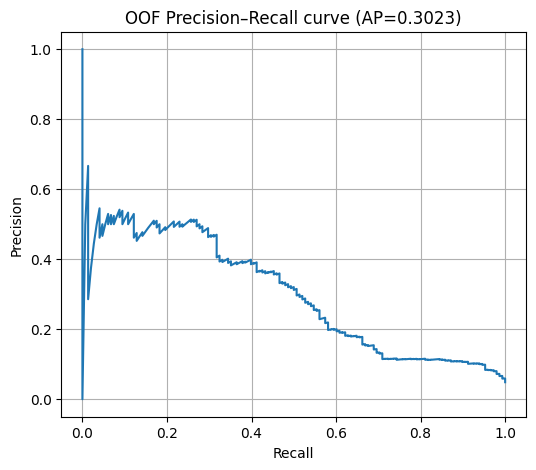

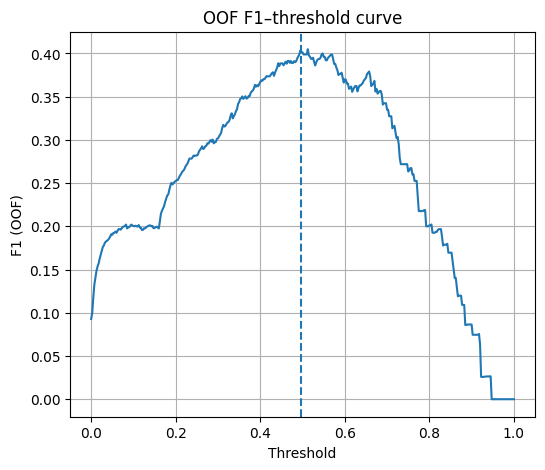

Best from grid: 0.40483383685800606 at thr= 0.5125
Best from search: 0.4046920821114369 at thr= 0.497


In [18]:
# --- Final summary table ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

summary_df = pd.DataFrame([dict(
    model="XGBoost (single)",
    table=use_tag,
    oof_f1=float(best_f1),
    best_th=float(best_th),
    n_features=int(X_all.shape[1]),
    best_n_estimators=int(best_n),
)])

display(summary_df)

# --- PR curve on OOF ---
prec, rec, thr = precision_recall_curve(y, oof_proba)
ap = average_precision_score(y, oof_proba)

plt.figure(figsize=(6, 5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"OOF Precision–Recall curve (AP={ap:.4f})")
plt.grid(True)
plt.show()

# --- F1 vs threshold on OOF ---
# Align thresholds: precision_recall_curve returns thr of length (len(prec)-1)
thr_grid = np.linspace(0, 1, 401)
f1_grid = []
for t in thr_grid:
    pred = (oof_proba >= t).astype(int)
    tp = ((pred == 1) & (y == 1)).sum()
    fp = ((pred == 1) & (y == 0)).sum()
    fn = ((pred == 0) & (y == 1)).sum()

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 0.0 if (precision + recall) == 0 else (2 * precision * recall) / (precision + recall)
    f1_grid.append(f1)

f1_grid = np.asarray(f1_grid)

plt.figure(figsize=(6, 5))
plt.plot(thr_grid, f1_grid)
plt.axvline(best_th, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("F1 (OOF)")
plt.title("OOF F1–threshold curve")
plt.grid(True)
plt.show()

# Print a compact view around best threshold
best_idx = int(np.nanargmax(f1_grid))
print("Best from grid:", float(f1_grid[best_idx]), "at thr=", float(thr_grid[best_idx]))
print("Best from search:", float(best_f1), "at thr=", float(best_th))


## 6. Suy luận trên test và tạo submission
- Tái tạo feature table cho test
- Encode nhất quán với train bằng `cat_maps` + `feature_cols`
- Xuất `submission.csv` (probability) và `submission_binary.csv` (0/1).

In [19]:

import pandas as pd
import numpy as np
import os, json, joblib, gc

# Load single model + metadata
model = joblib.load("best_xgb_single.pkl")
with open("best_xgb_meta.json") as f:
    meta = json.load(f)

BAND_MAP = meta["BAND_MAP"]
cat_maps = meta.get("cat_maps", {})
drop_cols = set(meta.get("drop_cols", []))
feature_cols = meta.get("feature_cols", [])

use_tag = meta.get("use_table", "BASE")
best_th = float(meta["best_th"])

print(">> Model Type: Single XGBoost")
print(">> use_table:", use_tag)
print(">> best_th:", best_th)

# Decide extract_fn by use_table
extract_fn = extract_features if use_tag == "BASE" else extract_features_prod

# Build test features
print(">> Building test features...")
df_feat_test = build_feature_table(meta_test, kind="test", extract_fn=extract_fn)
df_test = df_feat_test.merge(meta_test, on="object_id", how="left")
df_test = add_meta_interactions(df_test)

# Encode features
df_test_enc = df_test.copy()
if "shape_band" in df_test_enc.columns:
    df_test_enc["shape_band"] = df_test_enc["shape_band"].map(BAND_MAP).fillna(-1).astype(int)

X_test = df_test_enc.drop(["object_id","split"], axis=1, errors="ignore")

# Encode categorical columns using train mapping
for col, m in cat_maps.items():
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(str).fillna("__nan__").map(m).fillna(-1).astype(int)

# Drop constant columns from training
if drop_cols:
    X_test = X_test.drop(columns=[c for c in X_test.columns if c in drop_cols], errors="ignore")

# Ensure columns match training set
missing_cols = [c for c in feature_cols if c not in X_test.columns]
if missing_cols:
    for c in missing_cols:
        X_test[c] = 0

X_test = X_test[feature_cols]

# Predict probabilities
print(">> Generating predictions...")
proba = model.predict_proba(X_test)[:, 1]

# Create submission file with probabilities
sub = pd.DataFrame({
    "object_id": df_test_enc["object_id"].values,
    "prediction": proba
})

sub.to_csv("submission.csv", index=False)
print(f"\nSaved submission.csv with {len(sub)} predictions")
print(f"Prediction range: [{proba.min():.4f}, {proba.max():.4f}]")

sub.head()


>> Model Type: Single XGBoost
>> use_table: BASE
>> best_th: 0.497
>> Building test features...


/tmp/ipykernel_55/643122975.py:69: RuntimeWarning: All-NaN slice encountered
  base = float(np.nanmedian(early))
/tmp/ipykernel_55/643122975.py:71: RuntimeWarning: All-NaN slice encountered
  return base, peak, float(np.nanmedian(early)), peak


>> Generating predictions...

Saved submission.csv with 7135 predictions
Prediction range: [0.0009, 0.9670]


,object_id,prediction
0,Elrim_sador_hun,0.023398
1,Eluwaith_Mithrim_nothrim,0.012505
2,Eru_heledir_archam,0.013821
3,Gonhir_anann_fuin,0.007287
4,Gwathuirim_eilian_fervain,0.040779


### Chuyển probability → nhãn 0/1
Trong trường hợp bạn cần nộp submission dạng nhị phân, dùng `best_th` từ OOF để chuyển `prediction` (probability) thành nhãn 0/1.

In [20]:
import pandas as pd
import json

# Load threshold from metadata
with open("best_xgb_meta.json") as f:
    meta = json.load(f)

sub = pd.read_csv("submission.csv")  # probabilities from previous step
TH = float(meta.get("best_th", 0.5))  # best threshold từ OOF (fallback=0.5)

print(f"Using threshold: {TH:.4f}")
sub["prediction"] = (sub["prediction"] >= TH).astype(int)
sub[["object_id", "prediction"]].to_csv("submission_binary.csv", index=False)

print(f"\nBinary predictions saved to submission_binary.csv")
print(f"Class distribution: {sub['prediction'].value_counts().to_dict()}")
print(sub.head())

Using threshold: 0.4970

Binary predictions saved to submission_binary.csv
Class distribution: {0: 6786, 1: 349}
                   object_id  prediction
0            Elrim_sador_hun           0
1   Eluwaith_Mithrim_nothrim           0
2         Eru_heledir_archam           0
3          Gonhir_anann_fuin           0
4  Gwathuirim_eilian_fervain           0


## 7. Phân tích feature importance (tuỳ chọn)
Xem top features theo `feature_importances_` để kiểm tra nhanh mô hình đang dựa vào nhóm đặc trưng nào.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use model if available, else final_model
clf = model if 'model' in locals() else (final_model if 'final_model' in locals() else None)

if clf is None:
    print("Model variable not found (run previous cells to load 'model' or 'final_model').")
else:
    imp = getattr(clf, "feature_importances_", None)
    if imp is None:
        print("Model does not have feature_importances_.")
    else:
        # Create a DataFrame for visualization
        fi_df = pd.DataFrame({
            "feature": feature_cols,
            "importance": imp
        }).sort_values(by="importance", ascending=False).head(20)

        plt.figure(figsize=(12, 8))
        sns.barplot(data=fi_df, x="importance", y="feature", palette="viridis")
        plt.title("Top 20 Feature Importance")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

powerlaw_decay           0.062859
percentile_p10           0.023041
peak_width_50            0.019058
u_mean                   0.018582
r_peak_minus_base        0.016624
i_peak_minus_base        0.015944
u_cad_std                0.015153
exp_decay_k              0.013840
g_peak_minus_base        0.013231
rise_sharpness           0.012448
filter_drift             0.011405
Z                        0.011108
flux_clip_min            0.010365
flux_p99                 0.010343
peak_over_base           0.010293
flux_median              0.010081
flux_max                 0.009996
u_max                    0.009560
peak_flux                0.009129
r_std                    0.008897
energy                   0.008891
falling_tail_len         0.008729
peak_sig_over_ebv        0.008723
early_late_flux_ratio    0.008663
g_std                    0.008630
decay_time_90_10         0.008404
u_median                 0.008132
z_max                    0.007974
r_max                    0.007768
smoothness    